In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'sudoku.png'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(563, 558, 3)

In [3]:
def homography(src, dst):
    A, b = [], []
    for (x, y), (u, v) in zip(src, dst):
        A.append([x, y, 1, 0, 0, 0, -u * x, -u * y])
        b.append(u)
        A.append([0, 0, 0, x, y, 1, -v * x, -v * y])
        b.append(v)
    h = np.linalg.solve(np.array(A, dtype=np.float64), np.array(b, dtype=np.float64))
    return np.append(h, 1).reshape(3, 3)

In [4]:
h, w = img.shape[:2]
art = np.float64([[0, 0], [w, 0], [w, h], [0, h]])
quad = np.float64([[220, 120], [580, 120], [760, 640], [40, 640]])

photo = cv2.warpPerspective(img, homography(art, quad), (800, 700), borderValue=(120, 120, 120))
photo.shape

(700, 800, 3)

In [5]:
size = 500
square = np.float64([[0, 0], [size, 0], [size, size], [0, size]])

H = homography(quad, square)
fixed = cv2.warpPerspective(photo, H, (size, size))

print(np.round(H, 4))
print('matches cv2:', np.allclose(H, cv2.getPerspectiveTransform(np.float32(quad), np.float32(square)), atol=1e-3))

[[ 1.805600e+00  6.250000e-01 -4.722222e+02]
 [ 0.000000e+00  2.500000e+00 -3.000000e+02]
 [ 0.000000e+00  2.500000e-03  1.000000e+00]]
matches cv2: True


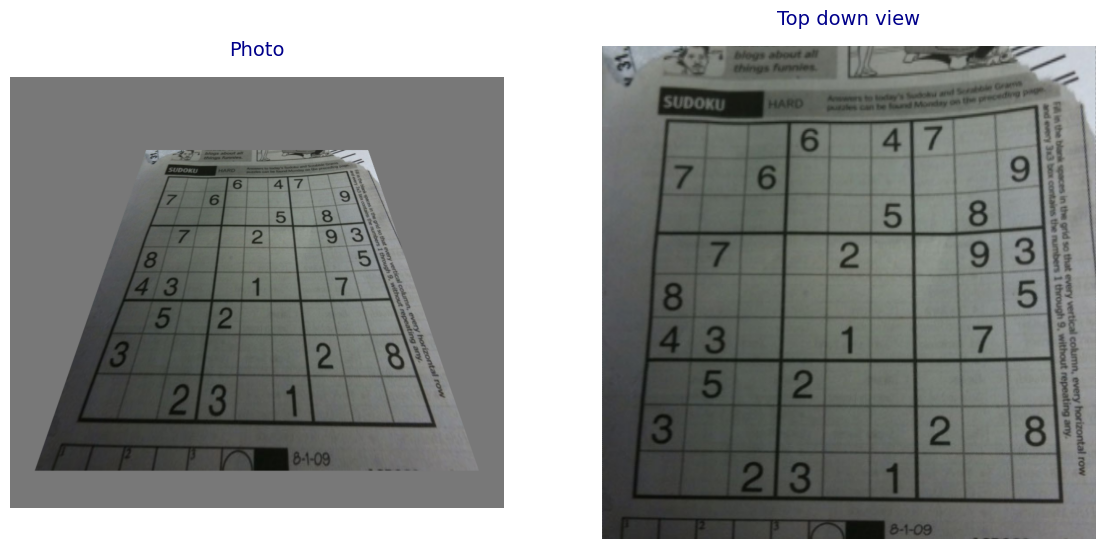

In [6]:
panels = [('Photo', photo), ('Top down view', fixed)]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task8_birdseye.png', cv2.cvtColor(fixed, cv2.COLOR_RGB2BGR))

True

The 4 corners are picked from the photo going clockwise from top left. The far edge is 360 px wide and the close edge is 720 px, which is the sidewalk effect.

Homography has 8 unknowns (the 9th entry is fixed to 1). Each corner pair gives 2 equations so 4 corners give exactly 8, solved with np.linalg.solve in the homography function. Matches cv2.getPerspectiveTransform.

Unlike affine, parallel lines don't stay parallel here. The bottom row of the matrix is not [0, 0, 1] and that is what lets the far edge be stretched wider to match the near edge.